In [27]:
import numpy as np
from numpy import dtype
import netCDF4 as nc
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import sklearn
from scipy import stats,signal
from scipy.spatial.distance import cdist
import datetime as dt
from datetime import date
import cartopy.crs as ccrs
import cartopy.feature as cf
import cartopy.mpl.ticker as cticker
import cftime
import dask
import collections
import scipy as scipy
from scipy.signal import detrend
from scipy import stats,signal
import cfgrib
import os
import glob
from yellowbrick.cluster import SilhouetteVisualizer
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
import matplotlib.dates as mdates
from collections import Counter
import matplotlib.lines as mlines

In [28]:
# Define the start and end years
start_year = 1990
end_year = 2024

# Generate all dates in April and May for each year from 1981 to 2023
dates = []
for year in range(start_year, end_year + 1):
    april_dates = [dt.date(year, 4, day) for day in range(1, 31)]
    may_dates = [dt.date(year, 5, day) for day in range(1, 32)]
    june_dates = [dt.date(year, 6, day) for day in range(1, 31)]
    july_dates = [dt.date(year, 7, day) for day in range(1, 32)]
    dates.extend(april_dates + may_dates + june_dates + july_dates)

# Convert to formatted string array
date_array = np.array([date.strftime("%Y-%m-%d") for date in dates])

# Display results
print(date_array)

['1990-04-01' '1990-04-02' '1990-04-03' ... '2024-07-29' '2024-07-30'
 '2024-07-31']


In [29]:
# Hail outbreak dates
import os
import glob
import pandas as pd
import numpy as np

# Set directory and get all hail CSV files

#hail_dir = '/file/path/directory/to/hail/files/'
hail_dir = '/glade/u/home/mgraber/Hail/'
os.chdir(hail_dir)

file_extension = '.csv'
all_filenames = glob.glob(f"*{file_extension}")

# Load all CSVs into one DataFrame
df = pd.concat(map(pd.read_csv, all_filenames), ignore_index=True)

# Keep relevant columns
df = df[['yr', 'date', 'mag', 'slat', 'slon']]

# Ensure 'date' is datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Filter for years 1960–2022

df = df[(df['date'].dt.year >= 1990) & (df['date'].dt.year <= 2024)]

# Apply significant hail magnitude thresholds (≥ 2.0 inches)
df_sig_hail_pre2010 = df[(df['date'] < '2010-01-01') & (df['mag'] >= 2.0)].copy()
df_sig_hail_post2010 = df[(df['date'] >= '2010-01-01') & (df['mag'] >= 2.0)].copy()
df_sig_hail = pd.concat([df_sig_hail_pre2010, df_sig_hail_post2010])

# Filter for months April–July (spring/summer core season)
df_sig_hail_spring = df_sig_hail[df_sig_hail['date'].dt.month.isin([4, 5, 6, 7])]

# Identify hail outbreak dates (days with >6 significant hail reports)
daily_counts = df_sig_hail_spring.groupby('date').size().reset_index(name='num_reports')
hail_outbreaks = daily_counts[daily_counts['num_reports'] > 6]

# Extract outbreak dates as a set
hail_outbreak_dates = set(hail_outbreaks['date'].dt.date)

# Convert to sorted NumPy array of strings
hail_outbreak_date_array = np.array(sorted(date.strftime("%Y-%m-%d") for date in hail_outbreak_dates))

# Display
print(hail_outbreak_date_array)
print(f"\nTotal hail outbreak days (≥7 sig hail reports): {len(hail_outbreak_date_array)}")


['1990-05-14' '1990-05-15' '1990-05-30' '1990-06-01' '1990-06-08'
 '1990-06-14' '1990-06-21' '1991-04-09' '1991-04-12' '1991-04-19'
 '1991-04-26' '1991-04-27' '1991-05-10' '1991-05-11' '1991-05-26'
 '1991-05-28' '1991-05-29' '1991-06-18' '1991-06-21' '1992-04-11'
 '1992-04-24' '1992-04-28' '1992-05-11' '1992-05-13' '1992-06-14'
 '1992-06-15' '1992-06-16' '1992-06-18' '1992-06-19' '1992-06-27'
 '1992-06-28' '1992-07-04' '1992-07-07' '1992-07-09' '1993-04-19'
 '1993-04-24' '1993-05-05' '1993-05-07' '1993-05-08' '1993-06-02'
 '1993-06-03' '1993-06-04' '1993-06-05' '1993-06-07' '1993-06-08'
 '1993-06-12' '1993-06-29' '1993-07-01' '1993-07-06' '1993-07-07'
 '1993-07-10' '1993-07-23' '1994-04-02' '1994-04-10' '1994-04-25'
 '1994-04-26' '1994-05-06' '1994-05-25' '1994-05-29' '1994-06-06'
 '1994-06-09' '1994-06-10' '1994-06-12' '1994-06-25' '1994-07-01'
 '1994-07-06' '1995-04-16' '1995-04-19' '1995-04-20' '1995-04-29'
 '1995-04-30' '1995-05-05' '1995-05-07' '1995-05-10' '1995-05-12'
 '1995-05-

In [30]:
os.chdir('/glade/u/home/mgraber/') 
Ensemble = np.load(f'labels_PROJ.npy')

In [31]:
# Stack the arrays horizontally to create a 2D array (dates, regime_numbers)
date_regime_array = np.column_stack((date_array, Ensemble))

In [32]:
# Create an empty list to store the date arrays for each regime
regime_dates = []

# Iterate through each regime (0 to 4)
for regime in range(5):
    # Filter the array for dates where the regime number is 'regime'
    dates_for_regime = date_regime_array[date_regime_array[:, 1].astype(int) == regime, 0]
    
    # Append the filtered dates to the list
    regime_dates.append(dates_for_regime)

# Optionally, if you want to store these arrays in separate variables
regime_0_dates = regime_dates[0]
regime_1_dates = regime_dates[1]
regime_2_dates = regime_dates[2]
regime_3_dates = regime_dates[3]
regime_4_dates = regime_dates[4]


In [33]:
# Inputs
regime_dates = [regime_0_dates, regime_1_dates, regime_2_dates, regime_3_dates, regime_4_dates]  # WR 0 to 4
hail_dates = np.array(hail_outbreak_date_array)
all_dates = np.array(date_array)

# Ensure datetime64[D] for comparison
hail_dates = hail_dates.astype('datetime64[D]')
all_dates = all_dates.astype('datetime64[D]')

# Climatological hail probability
Pc = (len(hail_dates) / len(all_dates)) * 100
print("Climatological hail probability (Pc):", Pc)

# Calculate WR hail probabilities and anomalies
hail_probabilities = []
anomalies = []
hail_day_timeseries = []
std_devs = []

years = np.arange(1990,2025)

for wr_dates in regime_dates:
    wr_dates = np.array(wr_dates).astype('datetime64[D]')
    
    # Intersection with hail days
    common = np.intersect1d(wr_dates, hail_dates)
    
    # Hail probability for this WR
    P_wr = (len(common) / len(wr_dates)) * 100
    hail_probabilities.append(P_wr)
    
    # Anomaly
    anomaly = ((P_wr - Pc) / Pc) * 100
    anomalies.append(anomaly)

    # Count hail days per year for this WR
    yearly_counts = []
    for y in years:
        mask = (common >= np.datetime64(f"{y}-01-01")) & (common <= np.datetime64(f"{y}-12-31"))
        yearly_counts.append(np.count_nonzero(mask))
    
    hail_day_timeseries.append(np.array(yearly_counts))

# Print results
print("Hail probabilities for each WR:", hail_probabilities)
print("Hail probability anomalies for each WR:", anomalies)

Climatological hail probability (Pc): 20.843091334894616
Hail probabilities for each WR: [14.610673665791776, 25.40106951871658, 21.308225966303272, 24.775583482944345, 19.362186788154897]
Hail probability anomalies for each WR: [-29.901599378729355, 21.86805263474132, 2.231600984398832, 18.86712524963184, -7.105013948964718]


In [11]:
import numpy as np

# Your inputs:
regime_dates = [regime_0_dates, regime_1_dates, regime_2_dates, regime_3_dates, regime_4_dates]  # WR 0 to 4
hail_dates= np.array(hail_outbreak_date_array)
all_dates = np.array(date_array)

# Ensure datetime64[D] for comparison
hail_dates = hail_dates.astype('datetime64[D]')
all_dates = all_dates.astype('datetime64[D]')

# Climatological hail probability
Pc = (len(hail_dates) / len(all_dates)) * 100
print("Climatological hail probability (Pc):", Pc)

# Prepare outputs
hail_probabilities = []
anomalies = []
tornado_day_timeseries = []
std_devs = []

years = np.arange(1990, 2025)

for i, wr_dates in enumerate(regime_dates):
    wr_dates = np.array(wr_dates).astype('datetime64[D]')
    
    # Intersection with tornado days
    common = np.intersect1d(wr_dates, tornado_dates)
    
    # Tornado probability for this WR
    P_wr = (len(common) / len(wr_dates)) * 100
    tornado_probabilities.append(P_wr)
    
    # Anomaly
    anomaly = ((P_wr - Pc) / Pc) * 100
    anomalies.append(anomaly)

    # Count tornado days per year for this WR
    yearly_counts = []
    for y in years:
        mask = (common >= np.datetime64(f"{y}-04-01")) & (common <= np.datetime64(f"{y}-07-31"))
        yearly_counts.append(np.count_nonzero(mask))
    
    yearly_counts = np.array(yearly_counts)
    tornado_day_timeseries.append(yearly_counts)

    # Standard deviation across years
    std_dev = np.std(yearly_counts, ddof=1)  # Sample standard deviation
    std_devs.append(std_dev)

    print(f"WR-{i}: Mean tornado days/year = {yearly_counts.mean():.2f}, Std = {std_dev:.2f}")

# Now you have `tornado_probabilities`, `anomalies`, `tornado_day_timeseries`, and `std_devs`


Climatological tornado probability (Pc): 20.843091334894616
WR-0: Mean tornado days/year = 4.77, Std = 4.53
WR-1: Mean tornado days/year = 8.14, Std = 5.23
WR-2: Mean tornado days/year = 6.14, Std = 2.96
WR-3: Mean tornado days/year = 3.94, Std = 2.92
WR-4: Mean tornado days/year = 2.43, Std = 2.46


In [12]:
PA = anomalies
model_probs = np.array(tornado_probabilities)/100

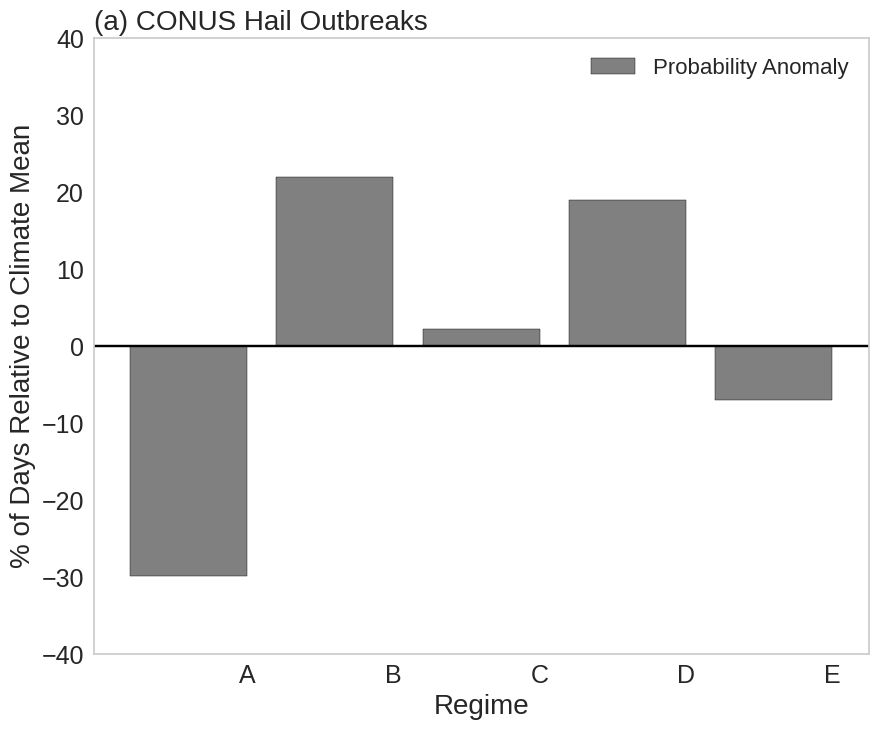

In [16]:
# Monte Carlo test in separate file
names = ['A','B','C', 'D','E']
days = [PA[0], PA[1], PA[2], PA[3], PA[4]]
df = pd.DataFrame({'days':days})
fig, axs = plt.subplots(1, 1, figsize=(10, 8))
df.days.plot(kind='bar', color='grey', ax=axs, width = 0.8, edgecolor = 'black',position=1)
axs.set_title(f'(a) CONUS Hail Outbreaks', loc='left', fontsize=20)
axs.set_xlabel('Regime', size = '20')
axs.set_ylabel('% of Days Relative to Climate Mean', size = '20')
axs.set_ylim(-40,40)
axs.tick_params(labelsize='18')
axs.set_xticklabels(names, rotation = 'horizontal', size='18')
axs.legend(labels =['Probability Anomaly'], fontsize=16, loc = 1)
axs.axhline(0, color='black')
axs.grid(False)

In [17]:
# Only on the ERA-5 Run
ERA5_1 = model_probs[0]
ERA5_2 = model_probs[1]
ERA5_3 = model_probs[2]
ERA5_4 = model_probs[3]
ERA5_5 = model_probs[4]

In [18]:
All_arrays = [regime_0_dates, regime_1_dates, regime_2_dates, regime_3_dates, regime_4_dates]
# Define the full range of years you want to account for (e.g., from 1981 to 2023)
full_year_range = np.array([str(year) for year in range(1990, 2025)])

# Initialize a list to hold the year count dictionaries for each array
year_count_dicts = []
year_count_arrays = []

# Loop over each date array
for date_array in All_arrays:
    # Extract the year from each date (first 4 characters)
    years = np.array([date[:4] for date in date_array])
    
    # Count occurrences of each year
    unique_years, year_counts = np.unique(years, return_counts=True)
    
    # Create a dictionary to map each year to its count
    year_count_dict = dict(zip(unique_years, year_counts))
    
    # Add missing years (those that appear in full_year_range but not in unique_years) with a count of 0
    for year in full_year_range:
        if year not in year_count_dict:
            year_count_dict[year] = 0
    
    # Add the year count dictionary to the list
    year_count_dicts.append(year_count_dict)
    
    # Convert the dictionary to a numpy array (ordered by full_year_range)
    year_array = np.array([year_count_dict[year] for year in full_year_range])
    
    # Add the array to the list of arrays
    year_count_arrays.append(year_array)


WRA = year_count_arrays[0]
WRB = year_count_arrays[1]
WRC = year_count_arrays[2]
WRD = year_count_arrays[3]
WRE = year_count_arrays[4]

In [19]:
# Model run
WR_A = (WRA *ERA5_1)
WR_B = (WRB *ERA5_2)
WR_C = (WRC *ERA5_3)
WR_D = (WRD *ERA5_4)
WR_E = (WRE *ERA5_5)



TI = WR_A + WR_B + WR_C + WR_D + WR_E


In [20]:
# Filter out dates from 1980
tornado_date_array = hail_outbreak_date_array[~np.char.startswith(hail_outbreak_date_array, "1989")]

# Extract the year from each date (first 4 characters)
years = np.array([date[:4] for date in tornado_date_array])

# Define the range of years (1990-2024)
full_year_range = np.array([str(year) for year in range(1990, 2025)])

# Initialize an array to store the count of days for each year
year_counts = np.zeros(len(full_year_range), dtype=int)

# Count occurrences of each year
for idx, year in enumerate(full_year_range):
    year_counts[idx] = np.sum(years == year)

TD_obs_nd = year_counts

In [21]:
year_counts=detrend(year_counts,type = 'linear')

In [22]:
cc, p = scipy.stats.spearmanr(year_counts, TI)

Text(0.0, 1.0, '(b) CONUS Modeled Hail Outbreaks with Detrended Observations')

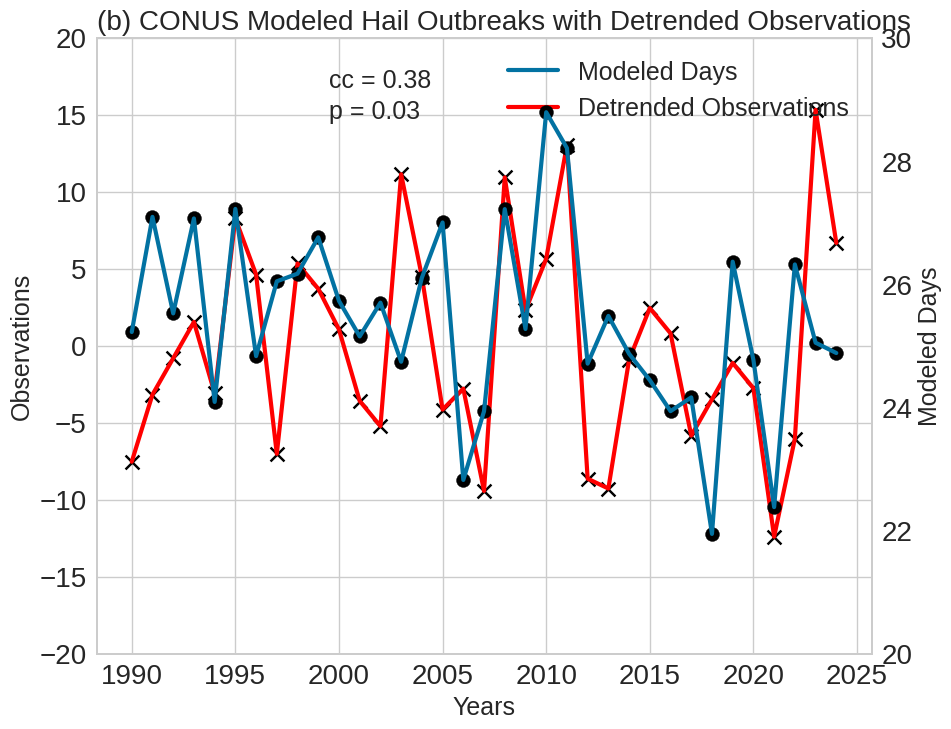

In [25]:
TD_obs = year_counts
save = '/glade/u/home/mgraber/'
years = np.arange(1990,2025)
fig, ax1 = plt.subplots(figsize=(10, 8))
ax2 = ax1.twinx()
ax2.plot(years, TI, label = 'Modeled Days', linewidth=3)
ax2.scatter(years, TI, color='black', s=100)
ax1.plot(years, year_counts, color='red', label = 'Detrended Observations', linewidth=3)
ax1.scatter(years, year_counts, marker='x', color='black', s=100)
ax1.tick_params(labelsize='20')
ax2.tick_params(labelsize='20')
ax1.set_xlabel('Years', size='18')
ax1.set_ylabel('Observations', size='18')
ax2.set_ylabel('Modeled Days', size='18')
ax2.set_ylim(20,30)
ax1.set_ylim(-20,20)
ax2.set_yticks(np.arange(20, 30.1,2))
ax1.text(.30, .95, f'cc = {cc:.2f}', ha='left', va='top', size=18, transform=ax1.transAxes)
ax1.text(.30, .9, f'p = {p:.2f}', ha='left', va='top', size=18, transform=ax1.transAxes)
ax1.grid(True)
ax2.grid(False)

# Combine the handles and labels from both axes
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax1.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc=1, fontsize=18)
plt.title(f'(b) CONUS Modeled Hail Outbreaks with Detrended Observations', loc='left', size='20')
